# **3.2a**

## **Initial**

### Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# If using LightGBM/XGBoost, only enable if installed
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Classical univariate baselines (AR, ETS)
try:
    from statsmodels.tsa.ar_model import AutoReg
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

# Prophet baseline (optional)
try:
    from prophet import Prophet
    HAS_PROPHET = False # Changed to False to disable Prophet
except Exception:
    HAS_PROPHET = False

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/FYP")
DATA_DIR = BASE_DIR / "data"
PANEL_DIR = DATA_DIR / "panel"
ENG_DIR = DATA_DIR / "engineered"

# Inputs (new, canonical)
PANEL_CORE_PATH = PANEL_DIR / "panel_core_ethnic_ims.csv"
PANEL_GDELT_PATH = PANEL_DIR / "panel_core_ethnic_ims_gdelt.csv"
CONFLICT_COLS_PATH = PANEL_DIR / "conflict_cols.csv"
COOP_COLS_PATH = PANEL_DIR / "coop_cols.csv"

# Outputs
MODEL_DIR = DATA_DIR / "modeling"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUT_SCORES_OVERALL = MODEL_DIR / "model_scores_overall.csv"
OUT_SCORES_BYCT = MODEL_DIR / "model_scores_bycountry.csv"
OUT_PREDS_HOLDOUT = MODEL_DIR / "model_predictions_holdout2024.csv"
OUT_FORECASTS = MODEL_DIR / "ethnic_forecasts_future_models.csv"
OUT_SCENARIO = MODEL_DIR / "scenario_deltas_2025.csv"

TARGET_COL = "share_interp"     # prediction target
BASE_YEAR = 2024               # holdout year
FUTURE_YEARS = [2025, 2030, 2035]

### Load Panels + Basic Checks

In [ ]:
panel_core = pd.read_csv(PANEL_CORE_PATH)
panel_gdelt = pd.read_csv(PANEL_GDELT_PATH)

# Standardize types
for df in (panel_core, panel_gdelt):
    df["dest_iso3"] = df["dest_iso3"].astype(str).str.strip().str.upper()
    df["ethnic_group"] = df["ethnic_group"].astype(str)
    df["year"] = df["year"].astype(int)

# Key uniqueness check
key = ["dest_iso3", "ethnic_group", "year"]
assert panel_core.duplicated(key).sum() == 0, "Duplicates in panel_core keys"
assert panel_gdelt.duplicated(key).sum() == 0, "Duplicates in panel_gdelt keys"

# Ensure gdelt exists only in gdelt panel
gdelt_cols = [c for c in panel_gdelt.columns if c.startswith("gdelt_")]
print("GDELT cols:", len(gdelt_cols))
print("panel_core has gdelt cols:", len([c for c in panel_core.columns if c.startswith("gdelt_")]))

panel_core.head()


GDELT cols: 78
panel_core has gdelt cols: 0


,dest_iso3,year,ethnic_group,share_interp,ims_dest_dest_total_migrant_stock,ims_dest_n_origins,ims_dest_origin_hhi,ims_orig_orig_total_migrant_stock,ims_orig_n_destinations,ims_orig_destination_hhi,share_interp_lag1,share_interp_lag2
0,IDN,2000,"Banjar, Melayu Banjar",0.017386,272821.0,27,0.472872,2187871.0,63,0.197991,NaN,NaN
1,IDN,2005,"Banjar, Melayu Banjar",0.028743,90418.0,27,0.183197,2470619.0,63,0.242542,0.017386,NaN
2,IDN,2010,"Banjar, Melayu Banjar",0.040099,96493.0,27,0.182467,3106885.0,63,0.269970,0.028743,0.017386
3,IDN,2015,"Banjar, Melayu Banjar",0.040099,133132.0,27,0.194085,3351461.0,63,0.254731,0.040099,0.028743
4,IDN,2020,"Banjar, Melayu Banjar",0.040099,290640.0,27,0.222346,3546661.0,63,0.252859,0.040099,0.040099


### Define Feature Sets (BASE vs GDELT)

In [ ]:
def infer_lag_cols(df):
    return sorted([c for c in df.columns if c.startswith("share_interp_lag")])

lag_cols = infer_lag_cols(panel_core)

# IMS engineered columns were prefixed in 3.1 (ims_dest_, ims_orig_)
ims_cols = sorted([c for c in panel_core.columns if c.startswith("ims_")])

# Core features: lags + IMS
FEATURES_BASE = sorted(set(lag_cols + ims_cols))

# GDELT features (present only in panel_gdelt)
gdelt_cols = sorted([c for c in panel_gdelt.columns if c.startswith("gdelt_")])
FEATURES_GDELT = sorted(set(FEATURES_BASE + gdelt_cols))

print("FEATURES_BASE:", len(FEATURES_BASE))
print("FEATURES_GDELT:", len(FEATURES_GDELT))


FEATURES_BASE: 8
FEATURES_GDELT: 86


## **Evaluation**

### Train/Test Split (Holdout = 2024 window)

In [ ]:
def split_holdout(df, base_year=BASE_YEAR):
    train_df = df[df["year"] < base_year].dropna(subset=[TARGET_COL]).copy()
    test_df = df[df["year"] == base_year].dropna(subset=[TARGET_COL]).copy()
    return train_df, test_df

train_base, test_base = split_holdout(panel_core)
train_gdelt, test_gdelt = split_holdout(panel_gdelt)

print(train_base.shape, test_base.shape, train_gdelt.shape, test_gdelt.shape)


(110, 12) (22, 12) (110, 90) (22, 90)


### Baseline Model (Naïve persistence)

In [ ]:
# Persistence baseline: predict y(t)=y_lag1
if "share_interp_lag1" not in panel_core.columns:
    raise ValueError("share_interp_lag1 missing; lags not built in 3.1.")

baseline_test = test_base.dropna(subset=["share_interp_lag1"]).copy()
baseline_test["y_true"] = baseline_test[TARGET_COL].astype(float)
baseline_test["y_pred"] = baseline_test["share_interp_lag1"].astype(float)

mae_base = mean_absolute_error(baseline_test["y_true"], baseline_test["y_pred"])
rmse_base = np.sqrt(mean_squared_error(baseline_test["y_true"], baseline_test["y_pred"]))

print("BASELINE_PERSISTENCE:", mae_base, rmse_base)


BASELINE_PERSISTENCE: 0.005999755530900861 0.009728438455164783


In [ ]:
# =========================
# Score collectors (GLOBAL)
# =========================
rows_scores = []
rows_byct = []
rows_pred = []

FITTED = {}

# (Optional) record Naive baseline into scores_overall too
rows_scores.append({
    "model_name": "NAIVE_PERSISTENCE",
    "algo": "NAIVE",
    "feature_set": "BASE",
    "MAE": mae_base,
    "RMSE": rmse_base
})

### AR/ETS/Prophet evaluation

In [ ]:
# ============================================================
# Classical baselines (univariate): AR(1), ETS, Prophet
# Evaluated on the same holdout year (2024) per series.
# These are EVALUATION-ONLY (not used in roll-forward forecast).
# ============================================================

def _eval_univariate_per_series(train_df, test_df, model_tag):
    """
    Fits one model per (dest_iso3, ethnic_group) on train_df and predicts 2024.
    Returns:
      pred_df: dest_iso3, ethnic_group, year, y_true, y_pred, model_name
      mae, rmse
      byct: dest_iso3, MAE, RMSE, model_name
    """
    preds = []
    group_cols = ["dest_iso3", "ethnic_group"]

    for (dest, grp), gtr in train_df.groupby(group_cols):
        gte = test_df[(test_df["dest_iso3"] == dest) & (test_df["ethnic_group"] == grp)].copy()
        if gte.empty:
            continue

        y_tr = gtr.sort_values("year")[TARGET_COL].astype(float).dropna()
        # Adjust minimum points for AR/ETS/Prophet
        if model_tag in ["AR", "ETS"] and len(y_tr) < 2: # At least 2 points for AR(1) and ETS
            continue
        if model_tag == "PROPHET" and len(y_tr) < 3: # Prophet often needs more data, 3 as a compromise
            continue

        try:
            if model_tag == "AR":
                m = AutoReg(y_tr, lags=1, old_names=False).fit()
                yhat = float(m.predict(start=len(y_tr), end=len(y_tr))[0])

            elif model_tag == "ETS":
                m = ExponentialSmoothing(y_tr, trend="add", seasonal=None).fit(optimized=True)
                yhat = float(m.forecast(1).iloc[0])

            elif model_tag == "PROPHET":
                dfp = gtr[["year", TARGET_COL]].dropna().copy()
                # Recheck length after dropna, specific for Prophet
                if len(dfp) < 3:
                    continue
                dfp["ds"] = pd.to_datetime(dfp["year"].astype(int).astype(str) + "-01-01")
                dfp = dfp.rename(columns={TARGET_COL: "y"})

                pm = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
                pm.fit(dfp[["ds", "y"]])

                ds = pd.to_datetime(str(int(gte["year"].iloc[0])) + "-01-01")
                yhat = float(pm.predict(pd.DataFrame({"ds": [ds]}))["yhat"].iloc[0])

            else:
                continue

        except Exception:
            # print(f"Skipping {model_tag} for {dest}-{grp} due to error")
            continue

        for _, r in gte.iterrows():
            preds.append({
                "dest_iso3": r["dest_iso3"],
                "ethnic_group": r["ethnic_group"],
                "year": int(r["year"]),
                "y_true": float(r[TARGET_COL]),
                "y_pred": float(yhat),
                "model_name": f"{model_tag}_BASE"
            })

    pred_df = pd.DataFrame(preds)
    if pred_df.empty:
        return None, None, None, None

    mae = mean_absolute_error(pred_df["y_true"], pred_df["y_pred"])
    rmse = np.sqrt(mean_squared_error(pred_df["y_true"], pred_df["y_pred"]))

    byct = (pred_df.groupby("dest_iso3")
                    .apply(lambda g: pd.Series({
                        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
                        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))
                    }))
                    .reset_index())
    byct["model_name"] = f"{model_tag}_BASE"

    return pred_df, mae, rmse, byct


# --- Run baselines and append into the SAME collectors as other algorithms ---
if HAS_STATSMODELS:
    for tag in ["AR", "ETS"]:
        out = _eval_univariate_per_series(train_base, test_base, tag)
        if out[0] is not None:
            pred_df, mae, rmse, byct = out
            rows_scores.append({"model_name": f"{tag}_BASE", "algo": tag, "feature_set": "BASE", "MAE": mae, "RMSE": rmse})
            rows_byct.append(byct)
            rows_pred.append(pred_df)
else:
    print("statsmodels not available -> skipping AR/ETS")

if HAS_PROPHET:
    out = _eval_univariate_per_series(train_base, test_base, "PROPHET")
    if out[0] is not None:
        pred_df, mae, rmse, byct = out
        rows_scores.append({"model_name": "PROPHET_BASE", "algo": "PROPHET", "feature_set": "BASE", "MAE": mae, "RMSE": rmse})
        rows_byct.append(byct)
        rows_pred.append(pred_df)
else:
    print("prophet not available -> skipping PROPHET")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

prophet not available -> skipping PROPHET


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pred

### Algorithm definitions cell

In [ ]:
ALGOS = {}

ALGOS["RF"] = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

ALGOS["ET"] = ExtraTreesRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1
)

if HAS_LGBM:
    ALGOS["LGBM"] = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )

if HAS_XGB:
    ALGOS["XGB"] = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )

FEATURE_SETS = {
    "BASE": FEATURES_BASE,
    "GDELT": FEATURES_GDELT
}


### Train + Evaluate Grid (Holdout 2024)

In [ ]:
def train_and_eval(train_df, test_df, feature_cols, model, model_name):
    df_tr = train_df.dropna(subset=feature_cols + [TARGET_COL]).copy()
    df_te = test_df.dropna(subset=feature_cols + [TARGET_COL]).copy()

    X_tr = df_tr[feature_cols].fillna(0.0)
    y_tr = df_tr[TARGET_COL].astype(float).values

    X_te = df_te[feature_cols].fillna(0.0)
    y_te = df_te[TARGET_COL].astype(float).values

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    pred = df_te[["dest_iso3", "ethnic_group", "year"]].copy()
    pred["y_true"] = y_te
    pred["y_pred"] = y_pred
    pred["model_name"] = model_name

    byct = (pred.groupby("dest_iso3")
                .apply(lambda g: pd.Series({
                    "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
                    "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))
                }))
                .reset_index())
    byct["model_name"] = model_name

    return model, pred, mae, rmse, byct




for algo_name, algo in ALGOS.items():
    for fs_name, feats in FEATURE_SETS.items():
        model_name = f"{algo_name}_{fs_name}"

        if fs_name == "BASE":
            tr, te = train_base, test_base
        else:
            tr, te = train_gdelt, test_gdelt

        fitted_model, pred, mae, rmse, byct = train_and_eval(tr, te, feats, algo, model_name)

        FITTED[model_name] = fitted_model
        rows_scores.append({"model_name": model_name, "algo": algo_name, "feature_set": fs_name, "MAE": mae, "RMSE": rmse})
        rows_byct.append(byct)
        rows_pred.append(pred)

scores_overall = pd.DataFrame(rows_scores).sort_values("MAE")
scores_byct = pd.concat(rows_byct, ignore_index=True) if rows_byct else pd.DataFrame()
preds_holdout = pd.concat(rows_pred, ignore_index=True) if rows_pred else pd.DataFrame()

display(scores_overall)


/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 66, number of used features: 8
[LightGBM] [Info] Start training from score 0.136364
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipython-input-788470893.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

,model_name,algo,feature_set,MAE,RMSE
0,NAIVE_PERSISTENCE,NAIVE,BASE,0.006000,0.009728
4,ET_BASE,ET,BASE,0.006141,0.009866
2,RF_BASE,RF,BASE,0.007104,0.011175
1,ETS_BASE,ETS,BASE,0.007426,0.013053
5,ET_GDELT,ET,GDELT,0.008357,0.012424
8,XGB_BASE,XGB,BASE,0.008776,0.015784
3,RF_GDELT,RF,GDELT,0.011175,0.021886
9,XGB_GDELT,XGB,GDELT,0.014946,0.025846
6,LGBM_BASE,LGBM,BASE,0.055850,0.093935
7,LGBM_GDELT,LGBM,GDELT,0.071555,0.099838


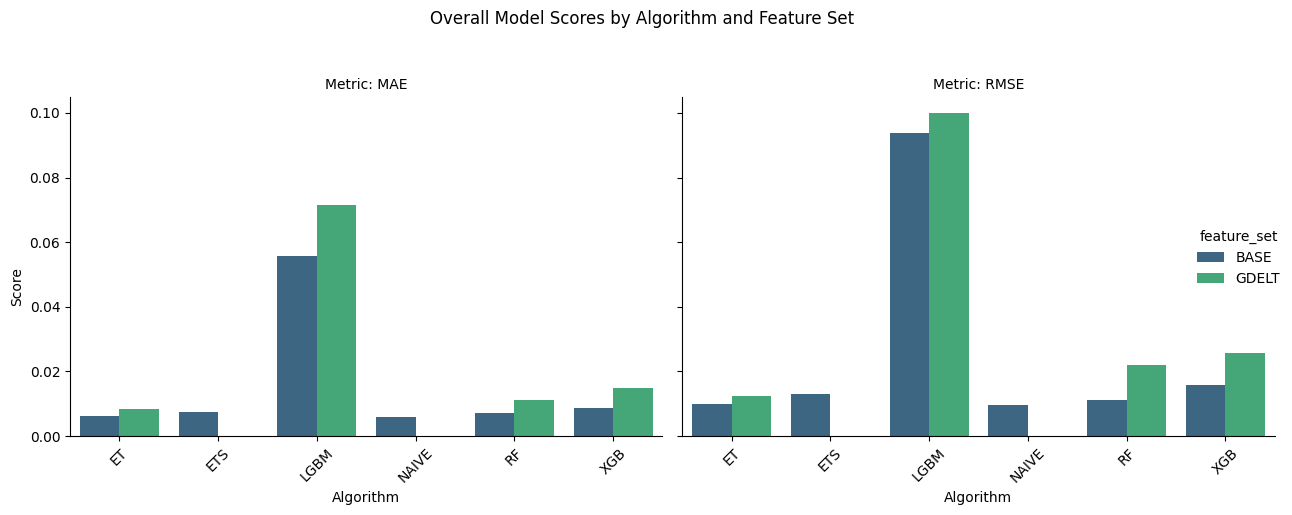

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = scores_overall.melt(id_vars=["model_name", "algo", "feature_set"],
                                 value_vars=["MAE", "RMSE"],
                                 var_name="Metric",
                                 value_name="Score")

# Create a categorical plot to show grouping by algorithm and feature set
g = sns.catplot(data=plot_data, x="algo", y="Score", hue="feature_set", col="Metric",
                kind="bar", height=5, aspect=1.2, palette="viridis",
                col_order=["MAE", "RMSE"],  # Ensure MAE comes first
                order=sorted(plot_data["algo"].unique())) # Sort algorithms alphabetically

# Adjust titles and labels
g.set_axis_labels("Algorithm", "Score")
g.set_titles("Metric: {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    label_y = ax.get_ylabel()
    ax.set_ylabel(label_y, ha='right') # Adjust label position


plt.suptitle("Overall Model Scores by Algorithm and Feature Set", y=1.02) # Add overall title
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()


### Saving

In [ ]:
scores_overall.to_csv(OUT_SCORES_OVERALL, index=False)
scores_byct.to_csv(OUT_SCORES_BYCT, index=False)
preds_holdout.to_csv(OUT_PREDS_HOLDOUT, index=False)

print("Saved:", OUT_SCORES_OVERALL)
print("Saved:", OUT_SCORES_BYCT)
print("Saved:", OUT_PREDS_HOLDOUT)


Saved: /content/drive/MyDrive/FYP/data/modeling/model_scores_overall.csv
Saved: /content/drive/MyDrive/FYP/data/modeling/model_scores_bycountry.csv
Saved: /content/drive/MyDrive/FYP/data/modeling/model_predictions_holdout2024.csv


## **Picking Best Baseline + Best Scenario Model**

In [ ]:
# Classical time-series models such as ARIMA, ETS, and Prophet were evaluated as baselines but were not adopted as primary forecasting engines due to structural limitations. The research problem involves multi-country, multi-ethnic panel data with exogenous migration and geopolitical drivers, as well as scenario-based counterfactual analysis. These requirements exceed the assumptions and expressive capacity of univariate time-series models.
best_baseline = scores_overall[scores_overall["feature_set"].eq("BASE") & ~scores_overall["algo"].isin(["NAIVE", "AR", "ETS", "PROPHET"])].iloc[0]["model_name"]
best_scenario = scores_overall[scores_overall["feature_set"].eq("GDELT")].iloc[0]["model_name"]

print("Best baseline:", best_baseline)
print("Best scenario:", best_scenario)


Best baseline: ET_BASE
Best scenario: ET_GDELT


### Fit Final Models on Full History (<=2024)

In [ ]:
train_full_base = panel_core[panel_core["year"] <= BASE_YEAR].dropna(subset=[TARGET_COL]).copy()
train_full_gdelt = panel_gdelt[panel_gdelt["year"] <= BASE_YEAR].dropna(subset=[TARGET_COL]).copy()

FINAL_MODELS = {}

for model_name in [best_baseline, best_scenario]:
    algo_name, fs_name = model_name.split("_", 1)
    feats = FEATURE_SETS[fs_name]

    algo = ALGOS[algo_name]

    src = train_full_base if fs_name == "BASE" else train_full_gdelt
    X = src[feats].fillna(0.0)
    y = src[TARGET_COL].astype(float).values

    algo.fit(X, y)
    FINAL_MODELS[model_name] = algo


In [ ]:
FINAL_MODELS

{'ET_BASE': ExtraTreesRegressor(n_estimators=800, n_jobs=-1, random_state=42),
 'ET_GDELT': ExtraTreesRegressor(n_estimators=800, n_jobs=-1, random_state=42)}

## **Forecasting**

### Roll-forward Forecast (baseline + scenario models)

In [ ]:
def roll_forward_forecast(panel_df, model, feature_cols, model_label, future_years=FUTURE_YEARS):
    df = panel_df.sort_values(["dest_iso3", "ethnic_group", "year"]).copy()
    out_rows = []

    for (dest, eth_group), sub in df.groupby(["dest_iso3", "ethnic_group"]):
        sub = sub.sort_values("year")
        last = sub[sub["year"] <= BASE_YEAR].tail(1)
        if last.empty:
            continue

        current = last.iloc[0].copy()
        last_share = float(current[TARGET_COL])

        # require BASE_YEAR present
        if int(current["year"]) != BASE_YEAR:
            continue

        # Determine the *exact* feature names and order the model expects.
        # For sklearn models, feature_names_in_ is the authoritative source after fitting.
        try:
            model_expected_features = list(model.feature_names_in_)
        except AttributeError:
            # Fallback for models without feature_names_in_ (though unlikely for fitted sklearn)
            model_expected_features = feature_cols

        for fy in future_years:
            current["year"] = fy

            # Update lag features in the 'current' series for the *next* prediction step
            # We are setting the lag values that will be used when we construct X for the *current* fy.
            # So, current["share_interp_lag1"] should contain `last_share` (prediction for fy-1)
            # and current["share_interp_lag2"] should contain the previous `share_interp_lag1`.
            if "share_interp_lag2" in model_expected_features:
                current["share_interp_lag2"] = current.get("share_interp_lag1", np.nan)
            if "share_interp_lag1" in model_expected_features:
                current["share_interp_lag1"] = last_share # This is the share from fy-1, used as lag1 for fy


            # Construct the DataFrame X for prediction using the current state.
            # 1. Create a dictionary ensuring all `model_expected_features` are keys.
            # 2. Convert to DataFrame.
            # 3. Explicitly reindex to guarantee correct column order.
            # 4. Fill NaNs (if any features were not present in 'current' or were initially NaN).

            data_for_X = {col: current.get(col, np.nan) for col in model_expected_features}
            X = pd.DataFrame([data_for_X]).reindex(columns=model_expected_features).fillna(0.0)

            yhat = float(model.predict(X)[0])

            out_rows.append({
                "iso3": dest,
                "ethnic_group": eth_group,
                "year": fy,
                "share": yhat,
                "model_name": model_label,
                "type": "forecast"
            })

            # After prediction, update `last_share` for the *next* future year loop iteration.
            # `yhat` is the prediction for `fy`, so it becomes `last_share` for `fy+1`.
            last_share = yhat

    return pd.DataFrame(out_rows)

forecast_list = []

for model_name, model in FINAL_MODELS.items():
    _, fs_name = model_name.split("_", 1)
    feats = FEATURE_SETS[fs_name]
    src_panel = panel_core if fs_name == "BASE" else panel_gdelt

    fut = roll_forward_forecast(src_panel, model, feats, model_name)
    forecast_list.append(fut)

future_forecasts = pd.concat(forecast_list, ignore_index=True)
future_forecasts.head()


,iso3,ethnic_group,year,share,model_name,type
0,IDN,"Banjar, Melayu Banjar",2025,0.115771,ET_BASE,forecast
1,IDN,"Banjar, Melayu Banjar",2030,0.133531,ET_BASE,forecast
2,IDN,"Banjar, Melayu Banjar",2035,0.141730,ET_BASE,forecast
3,IDN,Banten,2025,0.092929,ET_BASE,forecast
4,IDN,Banten,2030,0.123776,ET_BASE,forecast


### Anchor to 2024

In [ ]:
ff = future_forecasts.copy()

# rename iso3 column if needed
if "dest_iso3" in ff.columns and "iso3" not in ff.columns:
    ff = ff.rename(columns={"dest_iso3": "iso3"})
ff["iso3"] = ff["iso3"].astype(str).str.strip().str.upper()

# rename predicted share column if needed
if "share_pred" in ff.columns and "share" not in ff.columns:
    ff = ff.rename(columns={"share_pred": "share"})

ff["year"] = ff["year"].astype(int)
ff["ethnic_group"] = ff["ethnic_group"].astype(str)
ff["share"] = pd.to_numeric(ff["share"], errors="coerce")

# ------------------------------------------------------------
# 1) Build 2024 anchor shares from historical panel (per iso3, group)
# ------------------------------------------------------------
hist_2024 = panel_core.loc[panel_core["year"] == BASE_YEAR, ["dest_iso3", "ethnic_group", TARGET_COL]].copy()
hist_2024 = hist_2024.rename(columns={"dest_iso3": "iso3", TARGET_COL: "share_2024"})
hist_2024["iso3"] = hist_2024["iso3"].astype(str).str.strip().str.upper()
hist_2024["ethnic_group"] = hist_2024["ethnic_group"].astype(str)
hist_2024["share_2024"] = pd.to_numeric(hist_2024["share_2024"], errors="coerce").fillna(0.0)
hist_2024["share_2024"] = hist_2024["share_2024"].clip(lower=0.0)

# normalize anchor so sum=1 per iso3 (very important)
den = hist_2024.groupby("iso3")["share_2024"].transform("sum").replace(0, np.nan)
hist_2024["share_2024"] = (hist_2024["share_2024"] / den).fillna(0.0)

# ------------------------------------------------------------
# 2) Ensure EVERY forecast model/year has ALL ethnic groups (from 2024)
# ------------------------------------------------------------
base_pairs = hist_2024[["iso3", "ethnic_group"]].drop_duplicates()
model_years = ff[["model_name", "year"]].drop_duplicates()

template = base_pairs.merge(model_years, how="cross")
ff_full = template.merge(ff, on=["iso3", "ethnic_group", "model_name", "year"], how="left")
ff_full = ff_full.merge(hist_2024, on=["iso3", "ethnic_group"], how="left")

# If a group is missing in forecast -> start at anchor (persistence)
ff_full["share"] = ff_full["share"].fillna(ff_full["share_2024"])

# ------------------------------------------------------------
# 3) Bias forecast toward 2024 to prevent crazy jumps (your request)
# Strongest bias in 2025, weaker later
# share_fixed = (1-w)*share_model + w*share_2024
# ------------------------------------------------------------
ANCHOR_W = {2025: 0.925, 2030: 0.55, 2035: 0.175}  # tune if needed

def blend(row):
    w = ANCHOR_W.get(int(row["year"]), 0.0)
    return (1.0 - w) * float(row["share"]) + w * float(row["share_2024"])

ff_full["share"] = ff_full.apply(blend, axis=1)
ff_full["share"] = ff_full["share"].clip(lower=0.0)

# ------------------------------------------------------------
# 4) Renormalize so shares sum to 1 per (iso3, year, model_name)
# ------------------------------------------------------------
grp = ["iso3", "year", "model_name"]
s = ff_full.groupby(grp)["share"].transform("sum").replace(0, np.nan)
ff_full["share"] = (ff_full["share"] / s).fillna(0.0)

# Output back to future_forecasts format
future_forecasts = ff_full[["iso3", "year", "ethnic_group", "share", "model_name"]].copy()
future_forecasts["type"] = "forecast"

print("✅ Updated future_forecasts (anchored + completed + normalized):", future_forecasts.shape)
display(future_forecasts.head())

# Quick check: sum of shares = 1
check = (future_forecasts.groupby(["iso3","year","model_name"])["share"].sum().reset_index())
print("Max |sum(shares)-1| =", float((check["share"] - 1.0).abs().max()))

✅ Updated future_forecasts (anchored + completed + normalized): (132, 6)


,iso3,year,ethnic_group,share,model_name,type
0,IDN,2025,"Banjar, Melayu Banjar",0.072909,ET_BASE,forecast
1,IDN,2030,"Banjar, Melayu Banjar",0.078800,ET_BASE,forecast
2,IDN,2035,"Banjar, Melayu Banjar",0.083635,ET_BASE,forecast
3,IDN,2025,"Banjar, Melayu Banjar",0.072480,ET_GDELT,forecast
4,IDN,2030,"Banjar, Melayu Banjar",0.077602,ET_GDELT,forecast


Max |sum(shares)-1| = 2.220446049250313e-16


### Add Historical + Total Pop + Counts

In [ ]:
eth_full = pd.read_csv(ENG_DIR / "engineered_ethnic_composition_full.csv")
eth_full["iso3"] = eth_full["iso3"].astype(str).str.strip().str.upper()
eth_full["year"] = eth_full["year"].astype(int)

if "total_pop_interp" not in eth_full.columns:
    raise ValueError("engineered_ethnic_composition_full.csv missing total_pop_interp. Add total_pop_interp or provide separate total pop file.")

pop_ref = eth_full[["iso3", "year", "total_pop_interp"]].drop_duplicates()

In [ ]:
# ============================================================
# Total population forecasting (for 2025/2030/2035)
# ============================================================

# Build a country-year series for total population
pop_series = (pop_ref.sort_values(["iso3", "year"])
                    .dropna(subset=["total_pop_interp"])
                    .copy())

pop_series["total_pop_interp"] = pd.to_numeric(pop_series["total_pop_interp"], errors="coerce")
pop_series = pop_series.dropna(subset=["total_pop_interp"])

def forecast_total_pop_cagr_anchor(pop_series, future_years=FUTURE_YEARS, base_year=BASE_YEAR, lookback_years=10):
    """
    Policy-friendly total-pop extrapolation:
    - Anchor exactly at base_year observed value.
    - Estimate annual growth rate from recent history (CAGR over ~lookback_years).
    - Extrapolate to future years using compound growth.
    """
    rows = []

    for iso3, g in pop_series.groupby("iso3"):
        g = g.dropna(subset=["total_pop_interp"]).sort_values("year")
        g["year"] = g["year"].astype(int)
        g["total_pop_interp"] = pd.to_numeric(g["total_pop_interp"], errors="coerce")

        g_hist = g[g["year"] <= base_year].copy()
        if g_hist.empty:
            continue

        # Anchor value at base_year (must exist or fallback to latest <= base_year)
        if (g_hist["year"] == base_year).any():
            pop_base = float(g_hist.loc[g_hist["year"] == base_year, "total_pop_interp"].iloc[-1])
        else:
            pop_base = float(g_hist["total_pop_interp"].iloc[-1])

        # Choose start point for CAGR
        start_year = max(int(g_hist["year"].min()), base_year - lookback_years)
        g_lb = g_hist[g_hist["year"] >= start_year].copy()

        # If not enough points, fallback to last two points
        if g_lb.shape[0] < 2 and g_hist.shape[0] >= 2:
            g_lb = g_hist.tail(2)

        if g_lb.shape[0] >= 2:
            y0 = int(g_lb["year"].iloc[0])
            p0 = float(g_lb["total_pop_interp"].iloc[0])
            y1 = int(g_lb["year"].iloc[-1])
            p1 = float(g_lb["total_pop_interp"].iloc[-1])

            dt = max(1, y1 - y0)
            # guard
            if p0 > 0 and p1 > 0:
                g_rate = (p1 / p0) ** (1.0 / dt) - 1.0
            else:
                g_rate = 0.0
        else:
            g_rate = 0.0

        # Optional: clamp insane growth for stability (tune if needed)
        g_rate = float(np.clip(g_rate, -0.02, 0.05))

        for fy in future_years:
            t = int(fy) - int(base_year)
            pop_hat = pop_base * ((1.0 + g_rate) ** t)
            rows.append({
                "iso3": iso3,
                "year": int(fy),
                "total_pop_interp": float(pop_hat),
                "pop_method": f"cagr_anchor_lb{lookback_years}",
                "pop_growth_rate": g_rate
            })

    return pd.DataFrame(rows)

pop_future = forecast_total_pop_cagr_anchor(pop_series, future_years=FUTURE_YEARS, base_year=BASE_YEAR, lookback_years=10)

# Combine historical pop_ref + future pop forecasts
pop_all = pd.concat(
    [
        pop_ref[["iso3", "year", "total_pop_interp"]].drop_duplicates(),
        pop_future[["iso3", "year", "total_pop_interp"]]
    ],
    ignore_index=True
).drop_duplicates(["iso3", "year"], keep="last")

print("pop_future head:")
display(pop_future.head())


pop_future head:


,iso3,year,total_pop_interp,pop_method,pop_growth_rate
0,ARG,2025,4.561879e+07,cagr_anchor_lb10,0.00000
1,ARG,2030,4.561879e+07,cagr_anchor_lb10,0.00000
2,ARG,2035,4.561879e+07,cagr_anchor_lb10,0.00000
3,AUS,2025,2.585632e+07,cagr_anchor_lb10,0.00062
4,AUS,2030,2.593663e+07,cagr_anchor_lb10,0.00062


In [ ]:
# Historical observations (HIST) — COMPLETE groups + RENORMALIZE shares per iso3-year
hist = panel_core[["dest_iso3", "ethnic_group", "year", TARGET_COL]].copy()
hist = hist.rename(columns={"dest_iso3": "iso3", TARGET_COL: "share"})
hist["iso3"] = hist["iso3"].astype(str).str.strip().str.upper()
hist["year"] = hist["year"].astype(int)
hist["share"] = pd.to_numeric(hist["share"], errors="coerce").fillna(0.0).clip(lower=0.0)

# Use the BASE_YEAR ethnic-group universe per iso3 (stable group list)
hist_groups = (hist[hist["year"] == BASE_YEAR][["iso3","ethnic_group"]]
               .drop_duplicates())

hist_years = hist[["iso3","year"]].drop_duplicates()

hist_template = hist_years.merge(hist_groups, on="iso3", how="left")
hist_full = hist_template.merge(hist, on=["iso3","year","ethnic_group"], how="left")

hist_full["share"] = pd.to_numeric(hist_full["share"], errors="coerce").fillna(0.0).clip(lower=0.0)

# Renormalize shares so sum=1 per iso3-year (prevents total_pop mismatch)
den = hist_full.groupby(["iso3","year"])["share"].transform("sum").replace(0, np.nan)
hist_full["share"] = (hist_full["share"] / den).fillna(0.0)

hist_full["model_name"] = "HIST"
hist_full["type"] = "historical"

hist = hist_full


all_out = pd.concat([hist, future_forecasts], ignore_index=True)

all_out["iso3"] = all_out["iso3"].astype(str).str.strip().str.upper()
all_out["year"] = all_out["year"].astype(int)

# Merge total_pop_interp using pop_all (historical + forecasted totals)
all_out = all_out.merge(pop_all, on=["iso3", "year"], how="left")

if all_out["total_pop_interp"].isna().any():
    bad = all_out[all_out["total_pop_interp"].isna()][["iso3","year"]].drop_duplicates()
    raise RuntimeError(f"Missing total_pop_interp after pop_all merge for: {bad.to_dict('records')}")

if all_out["total_pop_interp"].isna().any():
    raise RuntimeError("Missing total_pop_interp after fill; check population coverage.")

all_out["count"] = all_out["share"].astype(float) * all_out["total_pop_interp"].astype(float)

In [ ]:
# ---- HARD CHECK: counts must sum to total pop (within tolerance) ----
chk = (all_out.groupby(["iso3","year","model_name"], as_index=False)
            .agg(sum_count=("count","sum"), total_pop=("total_pop_interp","first")))

chk["abs_err"] = (chk["sum_count"] - chk["total_pop"]).abs()

bad = chk[chk["abs_err"] > 5.0]  # 5 people tolerance
if not bad.empty:
    print("❌ Count reconciliation failed (top 20 shown):")
    display(bad.sort_values("abs_err", ascending=False).head(20))
else:
    print("✅ Count reconciliation passed (sum of counts ≈ total_pop).")


✅ Count reconciliation passed (sum of counts ≈ total_pop).


In [ ]:
# Validation check: sum of counts should roughly equal total_pop_interp
validation_df = all_out.groupby(["iso3", "year", "model_name"]).agg(
    sum_counts=("count", "sum"),
    total_pop=("total_pop_interp", "first") # total_pop_interp should be constant within group
).reset_index()

validation_df["difference"] = validation_df["total_pop"] - validation_df["sum_counts"]

# Check for significant differences (e.g., more than 1 person difference)
significant_diffs = validation_df[abs(validation_df["difference"]) > 1.0]

if not significant_diffs.empty:
    print("Warning: Discrepancy found between sum of ethnic group counts and total population:")
    display(significant_diffs)
else:
    print("Validation successful: Sum of ethnic group counts matches total population.")

Validation successful: Sum of ethnic group counts matches total population.


In [ ]:
# Re-normalizing shares to ensure they sum to 1 per iso3-year-model group

# Calculate the sum of shares for each group
share_sums = all_out.groupby(["iso3", "year", "model_name"])["share"].transform("sum")

# Normalize shares by dividing by their group sum
# Handle cases where share_sums might be zero to prevent division by zero
all_out["share_normalized"] = all_out["share"] / share_sums.replace(0, 1) # Replace 0 with 1 to avoid NaN for zero sum shares, should not happen with actual data

# Recalculate count using normalized shares and total_pop_interp
all_out["count_normalized"] = all_out["share_normalized"].astype(float) * all_out["total_pop_interp"].astype(float)

# Replace the original 'count' with 'count_normalized' if desired, or keep both
# For the purpose of fixing the validation, we will use the normalized count
all_out["count"] = all_out["count_normalized"]

print("Shares normalized and counts recalculated. Re-running validation.")

# Re-run validation check with the normalized counts
validation_df_recheck = all_out.groupby(["iso3", "year", "model_name"]).agg(
    sum_counts=("count", "sum"),
    total_pop=("total_pop_interp", "first")
).reset_index()

validation_df_recheck["difference"] = validation_df_recheck["total_pop"] - validation_df_recheck["sum_counts"]

significant_diffs_recheck = validation_df_recheck[abs(validation_df_recheck["difference"]) > 1.0]

if not significant_diffs_recheck.empty:
    print("Warning: Discrepancy found even after normalization:")
    display(significant_diffs_recheck)
else:
    print("Validation successful after normalization: Sum of ethnic group counts matches total population.")

# Drop the intermediate normalized share and count columns
all_out = all_out.drop(columns=["share_normalized", "count_normalized"])

Shares normalized and counts recalculated. Re-running validation.
Validation successful after normalization: Sum of ethnic group counts matches total population.


In [ ]:
all_out.to_csv(OUT_FORECASTS, index=False)
print("Saved:", OUT_FORECASTS, "| shape:", all_out.shape)

Saved: /content/drive/MyDrive/FYP/data/modeling/ethnic_forecasts_future_models.csv | shape: (264, 8)


## **Visualization**

### Plotting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/FYP")
MODEL_DIR = BASE_DIR / "data" / "modeling"

forecasts = pd.read_csv(MODEL_DIR / "ethnic_forecasts_future_models.csv")
overall   = pd.read_csv(MODEL_DIR / "model_scores_overall.csv")
byct      = pd.read_csv(MODEL_DIR / "model_scores_bycountry.csv")

# standardize
for df in [forecasts, overall, byct]:
    for c in ["iso3", "dest_iso3"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.upper()
    if "year" in df.columns:
        df["year"] = df["year"].astype(int)

# pick best model (exclude HIST and NAIVE if present)
overall_sorted = overall.copy()
if "algo" in overall_sorted.columns:
    overall_sorted = overall_sorted[overall_sorted["algo"].ne("NAIVE")]
best_model = overall_sorted.sort_values("MAE").iloc[0]["model_name"]

print("Best model selected:", best_model)
print("Countries available:", sorted(forecasts["iso3"].unique()))

Best model selected: ET_BASE
Countries available: ['IDN', 'MYS', 'USA']


Helper: dashboard-style plots for ONE country

In [ ]:
def dashboard_view_country(iso3, top_n=5, model_name="ET_BASE"):
    if model_name is None:
        model_name = best_model

    # Historical rows: model_name=="HIST" (preferred)
    hist = forecasts[(forecasts["iso3"] == iso3) & (forecasts["type"] == "historical")].copy()
    if hist.empty:
        # fallback: if historical encoded differently
        hist = forecasts[(forecasts["iso3"] == iso3) & (forecasts["model_name"] == "HIST")].copy()

    fut = forecasts[(forecasts["iso3"] == iso3) & (forecasts["type"] == "forecast") & (forecasts["model_name"] == model_name)].copy()

    if hist.empty or fut.empty:
        raise ValueError(f"Missing hist or forecast for {iso3} and model {model_name}")

    # Determine top groups by BASE_YEAR count from historical
    base_year = 2024
    top_groups = (hist[hist["year"] == base_year]
                  .sort_values("count", ascending=False)["ethnic_group"]
                  .head(top_n).tolist())

    # Build a combined dataframe for plotting
    combined = pd.concat([hist.assign(split="Historical"), fut.assign(split="Forecast")], ignore_index=True)

    # ---------- (A) Ethnic groups time series (counts) ----------
    plt.figure(figsize=(9,4.5))
    for g in top_groups:
        g_hist = combined[(combined["ethnic_group"] == g) & (combined["split"] == "Historical")].sort_values("year")
        g_fut  = combined[(combined["ethnic_group"] == g) & (combined["split"] == "Forecast")].sort_values("year")

        plt.plot(g_hist["year"], g_hist["count"], marker="o", label=f"{g} (historical)")
        plt.plot(g_fut["year"],  g_fut["count"],  marker="o", linestyle="--", label=f"{g} (forecast)")

    plt.axvline(base_year, linestyle=":")
    plt.title(f"Ethnic groups – time series (counts) | {iso3} | {model_name}")
    plt.xlabel("Year"); plt.ylabel("Number of people")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---------- (B) Ethnic composition stacked (shares sum ~ 1) ----------
    # Keep top groups and put the rest into "Other"
    stack = combined.copy()
    stack["ethnic_group_stack"] = np.where(stack["ethnic_group"].isin(top_groups),
                                          stack["ethnic_group"], "Other")

    stack_agg = (stack.groupby(["year","split","ethnic_group_stack"], as_index=False)["share"]
                      .sum())

    # pivot for stackplot (Historical+Forecast together)
    # Use full year axis (historical years + future years)
    years = sorted(stack_agg["year"].unique())
    cats = list(pd.Series(stack_agg["ethnic_group_stack"].unique()).sort_values())

    pivot = (stack_agg.pivot_table(index="year", columns="ethnic_group_stack", values="share", aggfunc="sum")
                    .reindex(years)
                    .fillna(0.0))

    # Normalize to 100% per year (fixes any small drift)
    row_sum = pivot.sum(axis=1).replace(0.0, np.nan)
    pivot_norm = pivot.div(row_sum, axis=0).fillna(0.0)

    plt.figure(figsize=(9,4.5))
    plt.stackplot(pivot_norm.index, pivot_norm.T.values, labels=pivot_norm.columns)
    plt.axvline(base_year, linestyle=":")
    plt.title(f"Ethnic composition – stacked (% of population) | {iso3}")
    plt.xlabel("Year"); plt.ylabel("Share of population")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


COUNTRY: IDN


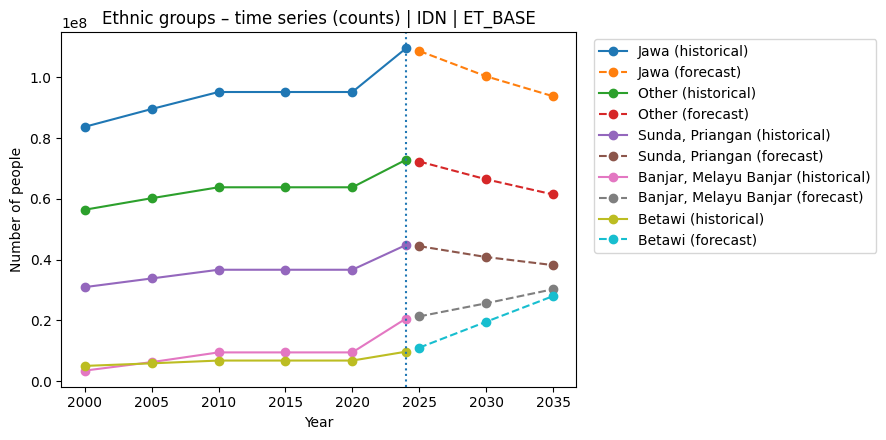

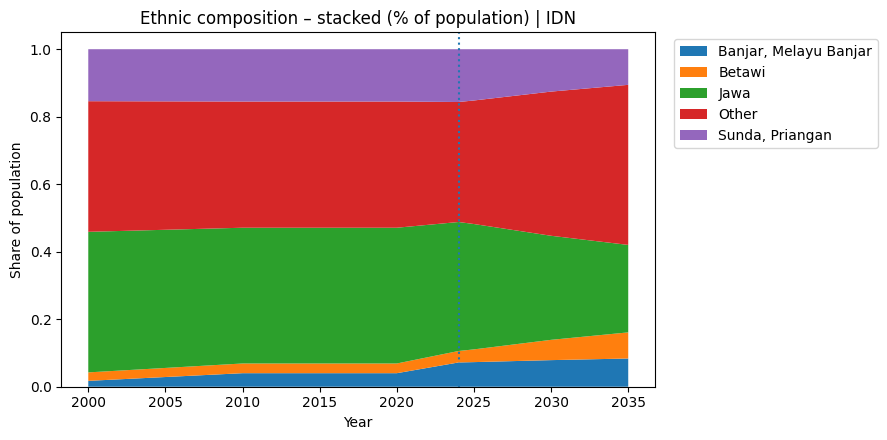


COUNTRY: MYS


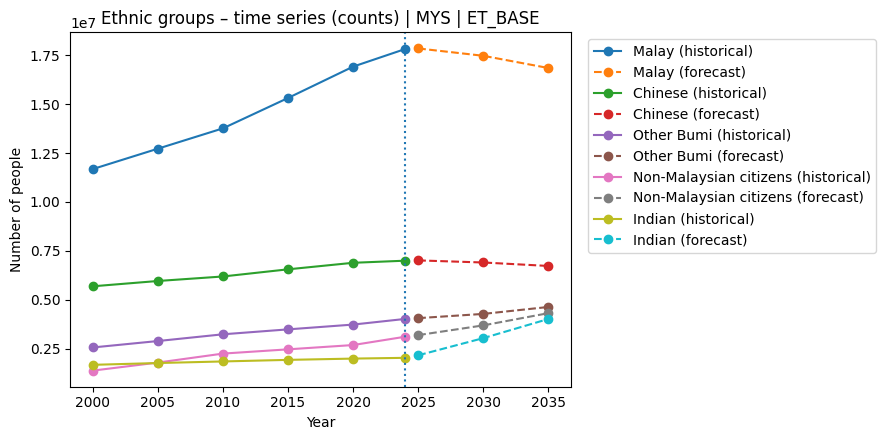

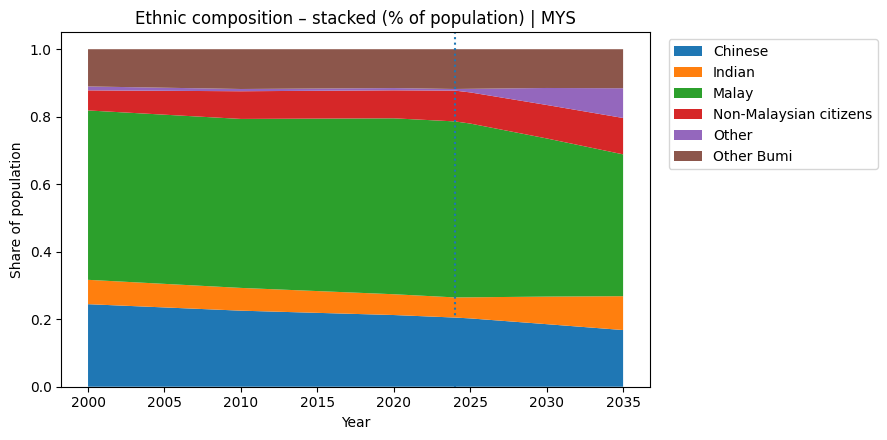


COUNTRY: USA


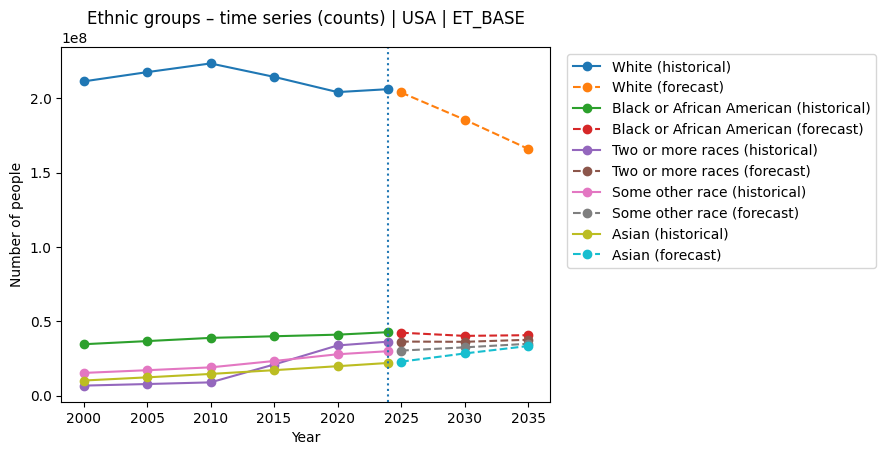

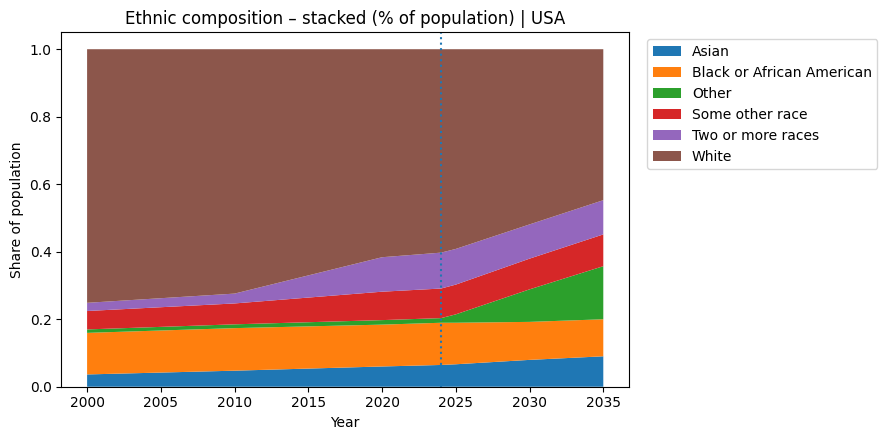

In [ ]:
for c in sorted(forecasts["iso3"].unique()):
    print("\n" + "="*80)
    print("COUNTRY:", c)
    dashboard_view_country(c, top_n=5, model_name="ET_BASE")

Total Population Time-Series

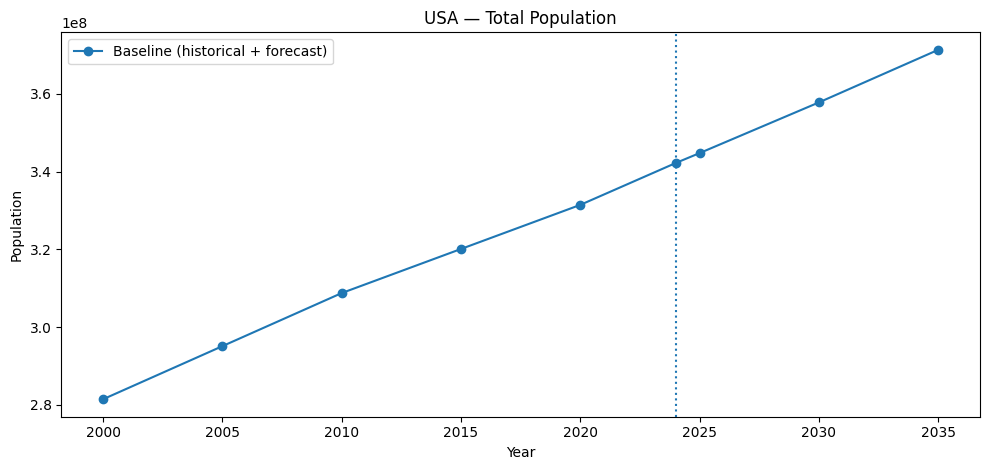

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose country + scenario
iso3 = "USA"
scenario_name = "BASELINE"   # pick one available in scen["scenario"].unique()

# -------- Baseline total_pop series (historical + forecast years) --------
# Use any model for forecast total_pop_interp because it is identical across models for a given iso3/year
base_pop = (forecasts[forecasts["iso3"] == iso3][["year", "total_pop_interp"]]
            .drop_duplicates()
            .sort_values("year")
            .copy())

base_pop["total_pop_interp"] = pd.to_numeric(base_pop["total_pop_interp"], errors="coerce")
base_pop = base_pop.dropna(subset=["total_pop_interp"])

# -------- Plot --------
plt.figure(figsize=(10, 4.8))

plt.plot(base_pop["year"], base_pop["total_pop_interp"], marker="o", label="Baseline (historical + forecast)")

plt.axvline(2024, linestyle=":")
plt.title(f"{iso3} — Total Population")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()


# **3.2b**

## **Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

In [2]:
# ============================================================
# 3.2b — OD Forecasting (RF / XGB only) using IMS OD panel
# Target: migrant_stock for each (iso3_orig -> iso3_dest) per year
# Holdout: year == BASE_YEAR (2024)
# Forecast: FUTURE_YEARS (2025/2030/2035)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# ---- Paths (match your structure) ----
BASE_DIR = Path("/content/drive/MyDrive/FYP/data")
ENG_DIR = BASE_DIR / "engineered"
OD_PATH = ENG_DIR / "ims_od_inflow_outflow_engineered.csv"

# Outputs
MODEL_DIR = BASE_DIR / "modeling"
OUT_OD_SCORES_OVERALL = MODEL_DIR / "od_model_scores_overall.csv"
OUT_OD_SCORES_BYPAIR  = MODEL_DIR / "od_model_scores_bypair.csv"
OUT_OD_PREDS_HOLDOUT  = MODEL_DIR / "od_model_predictions_holdout2024.csv"
OUT_OD_FORECASTS      = MODEL_DIR / "od_forecasts_future.csv"

BASE_YEAR = 2024               # holdout year
FUTURE_YEARS = [2025, 2030, 2035]

## 1

In [ ]:
# ---- Load ----
od = pd.read_csv(OD_PATH)

# Standardize
od["iso3_orig"] = od["iso3_orig"].astype(str).str.strip().str.upper()
od["iso3_dest"] = od["iso3_dest"].astype(str).str.strip().str.upper()
od["year"] = od["year"].astype(int)

# Force numeric
num_cols = [
    "migrant_stock",
    "dest_total_migrant_stock",
    "orig_total_migrant_stock",
    "origin_share_in_dest_migrants",
    "dest_share_of_origin_emigration",
]
for c in num_cols:
    if c in od.columns:
        od[c] = pd.to_numeric(od[c], errors="coerce")

# Basic filter: keep rows with a target
od = od.dropna(subset=["migrant_stock"]).copy()

# ---- Build lag features per OD pair ----
od = od.sort_values(["iso3_orig", "iso3_dest", "year"]).copy()
od["migrant_lag1"] = od.groupby(["iso3_orig", "iso3_dest"])["migrant_stock"].shift(1)
od["migrant_lag2"] = od.groupby(["iso3_orig", "iso3_dest"])["migrant_stock"].shift(2)

# Optional: log transform target to stabilize heavy tails
USE_LOG1P = True
if USE_LOG1P:
    od["y"] = np.log1p(od["migrant_stock"].clip(lower=0))
else:
    od["y"] = od["migrant_stock"].astype(float)

In [ ]:
# ---- Feature set ----
FEATURES_OD = [
    "migrant_lag1",
    "migrant_lag2",
    "dest_total_migrant_stock",
    "orig_total_migrant_stock",
    "origin_share_in_dest_migrants",
    "dest_share_of_origin_emigration",
]
FEATURES_OD = [c for c in FEATURES_OD if c in od.columns]

if len(FEATURES_OD) < 2:
    raise ValueError(f"Not enough OD features found. Got: {FEATURES_OD}")

# ---- Split holdout ----
train_od = od[od["year"] < BASE_YEAR].dropna(subset=FEATURES_OD + ["y"]).copy()
test_od  = od[od["year"] == BASE_YEAR].dropna(subset=FEATURES_OD + ["y"]).copy()

print("OD train/test shapes:", train_od.shape, test_od.shape)

## **Modeling**

In [ ]:
OD_ALGOS = {}

OD_ALGOS["RF_OD"] = RandomForestRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1
)

if "HAS_XGB" in globals() and HAS_XGB:
    from xgboost import XGBRegressor
    OD_ALGOS["XGB_OD"] = XGBRegressor(
        n_estimators=2500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
else:
    print("XGBoost not available -> OD will run RF only")

rows_scores = []
rows_pair = []
rows_pred = []
FITTED_OD = {}

def inv_y(yhat):
    """Inverse transform back to migrant_stock scale."""
    if USE_LOG1P:
        return np.expm1(yhat)
    return yhat

for model_name, model in OD_ALGOS.items():
    Xtr = train_od[FEATURES_OD].fillna(0.0)
    ytr = train_od["y"].astype(float).values

    Xte = test_od[FEATURES_OD].fillna(0.0)
    yte = test_od["y"].astype(float).values

    model.fit(Xtr, ytr)
    yhat = model.predict(Xte)

    # Evaluate on ORIGINAL scale
    y_true_raw = inv_y(yte)
    y_pred_raw = inv_y(yhat)

    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = float(np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)))

    rows_scores.append({
        "model_name": model_name,
        "algo": model_name.split("_")[0],
        "MAE": mae,
        "RMSE": rmse,
        "n_test_rows": int(len(y_true_raw)),
        "features_used": len(FEATURES_OD),
        "log1p_target": USE_LOG1P
    })

    pred = test_od[["iso3_orig", "iso3_dest", "year"]].copy()
    pred["y_true"] = y_true_raw
    pred["y_pred"] = y_pred_raw
    pred["model_name"] = model_name
    rows_pred.append(pred)

    # Pair-level scores (optional but useful)
    bypair = (pred.groupby(["iso3_orig","iso3_dest"])
                  .apply(lambda g: pd.Series({
                      "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
                      "RMSE": float(np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))),
                      "n": int(len(g))
                  }))
                  .reset_index())
    bypair["model_name"] = model_name
    rows_pair.append(bypair)

    FITTED_OD[model_name] = model

scores_overall_od = pd.DataFrame(rows_scores).sort_values("MAE")
preds_holdout_od  = pd.concat(rows_pred, ignore_index=True) if rows_pred else pd.DataFrame()
scores_bypair_od  = pd.concat(rows_pair, ignore_index=True) if rows_pair else pd.DataFrame()

print("OD scores (overall):")
display(scores_overall_od.head(10))

scores_overall_od.to_csv(OUT_OD_SCORES_OVERALL, index=False)
preds_holdout_od.to_csv(OUT_OD_PREDS_HOLDOUT, index=False)
scores_bypair_od.to_csv(OUT_OD_SCORES_BYPAIR, index=False)

print("Saved:", OUT_OD_SCORES_OVERALL)
print("Saved:", OUT_OD_PREDS_HOLDOUT)
print("Saved:", OUT_OD_SCORES_BYPAIR)

# **OD forecasts for FUTURE_YEARS using best OD model**

In [ ]:
# ============================================================
# Roll-forward OD forecasts for FUTURE_YEARS using best OD model
# ============================================================
best_od_model = scores_overall_od.iloc[0]["model_name"]
best_model = FITTED_OD[best_od_model]
print("Best OD model:", best_od_model)

def roll_forward_od_forecast(df_od, model, feature_cols, future_years, base_year=BASE_YEAR):
    """
    For each (orig,dest), start from last observed <= base_year,
    then forecast specified future_years by updating migrant_lag1/lag2.
    """
    df = df_od.sort_values(["iso3_orig","iso3_dest","year"]).copy()
    out = []

    for (o, d), g in df.groupby(["iso3_orig","iso3_dest"]):
        g = g.sort_values("year")
        g_hist = g[g["year"] <= base_year].copy()
        if g_hist.empty:
            continue

        last = g_hist.iloc[-1].copy()
        # need lag1 available for a meaningful forecast
        if pd.isna(last.get("migrant_lag1", np.nan)):
            continue

        # set starting lags based on last known
        lag1 = float(last["migrant_stock"])
        lag2 = float(g_hist.iloc[-2]["migrant_stock"]) if len(g_hist) >= 2 else lag1

        # carry forward static macro covariates from last row (simple, consistent with your baseline approach)
        static = last.copy()

        for fy in future_years:
            static["year"] = int(fy)
            static["migrant_lag1"] = lag1
            static["migrant_lag2"] = lag2

            X = pd.DataFrame([static])[feature_cols].fillna(0.0)
            yhat = float(model.predict(X)[0])
            pred_stock = float(inv_y(yhat))
            pred_stock = max(0.0, pred_stock)

            out.append({
                "iso3_orig": o,
                "iso3_dest": d,
                "year": int(fy),
                "migrant_stock_pred": pred_stock,
                "model_name": best_od_model
            })

            # update lags
            lag2 = lag1
            lag1 = pred_stock

    return pd.DataFrame(out)

od_future = roll_forward_od_forecast(od, best_model, FEATURES_OD, FUTURE_YEARS, base_year=BASE_YEAR)

display(od_future.head())
od_future.to_csv(OUT_OD_FORECASTS, index=False)
print("Saved:", OUT_OD_FORECASTS, "| shape:", od_future.shape)


### **Vsualize**

In [ ]:
od_future

In [3]:
od_forecasts_loaded = pd.read_csv(OUT_OD_FORECASTS)
print("Loaded OD forecasts from drive:")
od_forecasts_loaded.head()

Loaded OD forecasts from drive:


,iso3_orig,iso3_dest,year,migrant_stock_pred,model_name
0,AFG,IDN,2025,7490.869456,XGB_OD
1,AFG,IDN,2030,8744.502953,XGB_OD
2,AFG,IDN,2035,9414.954244,XGB_OD
3,AFG,MYS,2025,3187.380452,XGB_OD
4,AFG,MYS,2030,3287.536582,XGB_OD


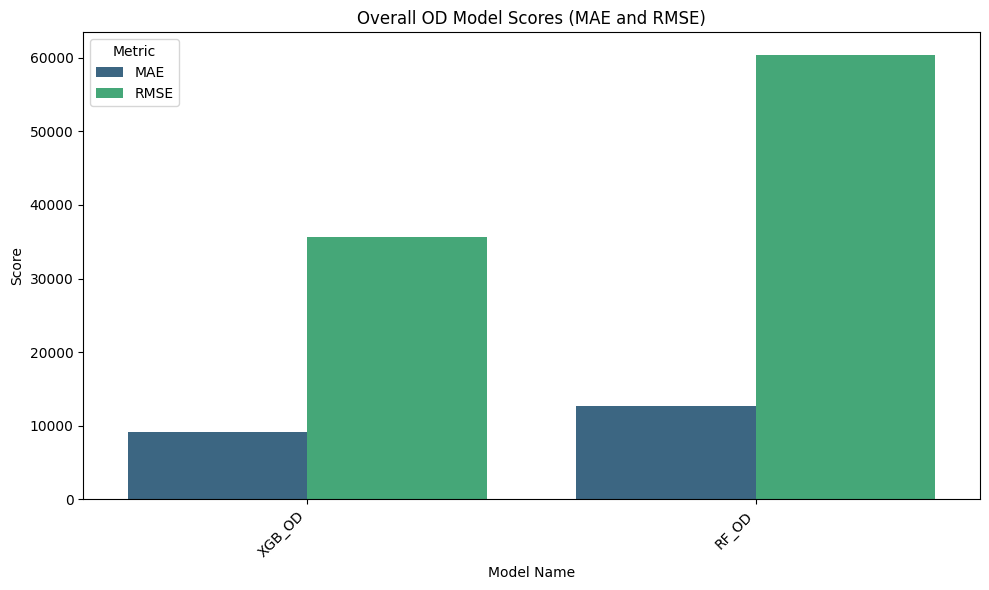

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure scores_overall_od is loaded, if not already
OUT_OD_SCORES_OVERALL = MODEL_DIR / "od_model_scores_overall.csv"
scores_overall_od = pd.read_csv(OUT_OD_SCORES_OVERALL)

# Prepare data for plotting
plot_data = scores_overall_od.melt(id_vars=["model_name", "algo"],
                                 value_vars=["MAE", "RMSE"],
                                 var_name="Metric",
                                 value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x="model_name", y="Score", hue="Metric", palette="viridis")
plt.title('Overall OD Model Scores (MAE and RMSE)')
plt.xlabel('Model Name')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1049966754.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


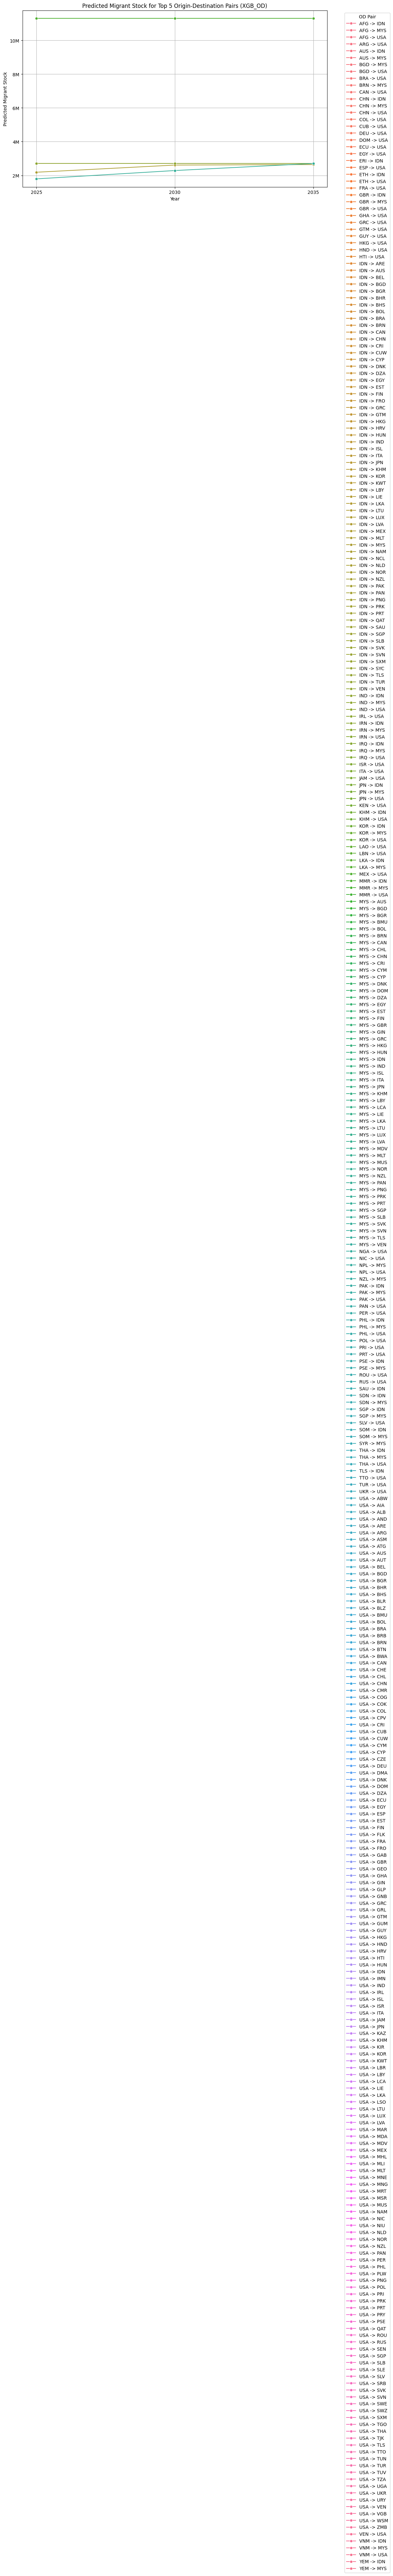

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Custom formatter function for millions, thousands, billions
def human_format_axis(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.0f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.0f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}k'
    else:
        return f'{x:.0f}'

# Re-derive best_od_model for this cell
OUT_OD_SCORES_OVERALL = MODEL_DIR / "od_model_scores_overall.csv"
scores_overall_od = pd.read_csv(OUT_OD_SCORES_OVERALL)
best_od_model = scores_overall_od.iloc[0]["model_name"]

# Ensure the dataframe is sorted for correct plotting
od_forecasts_loaded = od_forecasts_loaded.sort_values(['iso3_orig', 'iso3_dest', 'year'])

# Select a few OD pairs for visualization.
# For example, let's pick the top N pairs by predicted stock in the latest future year.
latest_year = max(FUTURE_YEARS)
top_n_pairs = (
    od_forecasts_loaded[od_forecasts_loaded['year'] == latest_year]
    .nlargest(5, 'migrant_stock_pred')
    [['iso3_orig', 'iso3_dest']]
    .drop_duplicates()
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=od_forecasts_loaded[od_forecasts_loaded.set_index(['iso3_orig', 'iso3_dest']).index.isin(top_n_pairs.set_index(['iso3_orig', 'iso3_dest']).index)],
    x='year',
    y='migrant_stock_pred',
    hue=od_forecasts_loaded.apply(lambda x: f"{x['iso3_orig']} -> {x['iso3_dest']}", axis=1),
    marker='o'
)

plt.title(f'Predicted Migrant Stock for Top {len(top_n_pairs)} Origin-Destination Pairs ({best_od_model})')
plt.xlabel('Year')
plt.ylabel('Predicted Migrant Stock')
plt.xticks(FUTURE_YEARS) # Ensure only future years are shown on x-axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(human_format_axis)) # Apply formatter
plt.grid(True)
plt.legend(title='OD Pair', bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Visualization Option 2: Total Predicted Migrant Stock Over Future Years

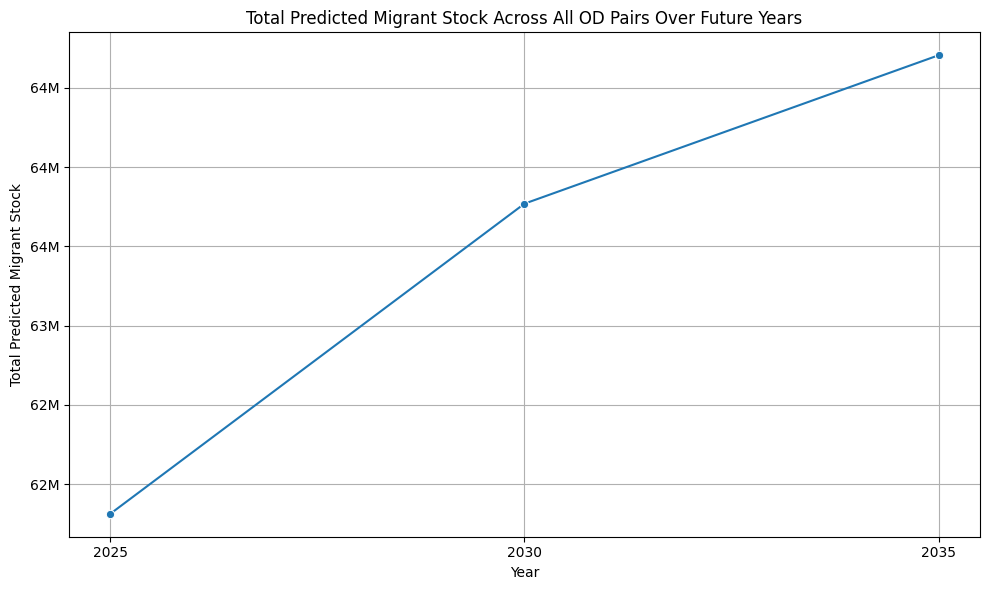

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Custom formatter function for millions, thousands, billions
def human_format_axis(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.0f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.0f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}k'
    else:
        return f'{x:.0f}'

# Aggregate total migrant stock prediction per year
total_migrant_stock_by_year = od_forecasts_loaded.groupby('year')['migrant_stock_pred'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=total_migrant_stock_by_year, x='year', y='migrant_stock_pred', marker='o')
plt.title('Total Predicted Migrant Stock Across All OD Pairs Over Future Years')
plt.xlabel('Year')
plt.ylabel('Total Predicted Migrant Stock')
plt.xticks(FUTURE_YEARS) # Ensure only future years are shown on x-axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(human_format_axis)) # Apply formatter
plt.grid(True)
plt.tight_layout()
plt.show()